# Notebook 03 — Hybrid M2: CRNN + Lexicon-Constrained Decoding


##  Environment, config, and shared components
We reuse the baseline's Vocab / Dataset / metrics / CRNN definition unchanged so the loaded
checkpoint matches exactly. (In a refactor these live in a shared module.)

In [11]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import random
import time
from dataclasses import dataclass
from functools import partial
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = (torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cuda") if torch.cuda.is_available()
          else torch.device("cpu"))
print(f"Using device: {DEVICE} | torch {torch.__version__}")

Using device: mps | torch 2.12.0


In [12]:
@dataclass
class Config:
    data_root: Path = Path("../data/pharmacy_lk")
    train_csv: str = "splits/train.csv"
    val_csv: str = "splits/val.csv"
    test_csv: str = "splits/test.csv"
    img_dir: str = "images"
    img_col: str = "image_filename"
    label_col: str = "medicine_name"

    img_height: int = 48
    img_width: int = 320

    rnn_hidden: int = 256
    rnn_layers: int = 2
    dropout: float = 0.2

    batch_size: int = 64
    num_workers: int = 0

    # checkpoint of the TRAINED baseline CRNN (produced by Notebook 01b)
    baseline_ckpt: Path = Path("../checkpoints/baseline_crnn_v2/best.pt")
    # OPTIONAL external formulary: a plain-text file, one medicine name per line.
    # Leave as None to use the training-vocabulary lexicon only.
    formulary_path: "Path | None" = None      # e.g. Path("../data/pharmacy_lk/formulary.txt")
    out_dir: Path = Path("../checkpoints/hybrid_m2")

CFG = Config()
CFG.out_dir.mkdir(parents=True, exist_ok=True)

### 2.1 Vocab, Dataset, metrics, CRNN (identical to baseline 01b)

In [13]:
class Vocab:
    BLANK = 0
    def __init__(self, texts):
        chars = sorted(set("".join(texts)))
        self.idx2char = {i + 1: c for i, c in enumerate(chars)}
        self.char2idx = {c: i for i, c in self.idx2char.items()}
    def __len__(self):
        return len(self.idx2char) + 1
    def encode(self, text):
        return [self.char2idx[c] for c in text]
    def decode_greedy(self, indices):
        out, prev = [], None
        for i in indices:
            if i != prev and i != self.BLANK:
                # guard: unseen index (shouldn't happen) -> skip
                if i in self.idx2char:
                    out.append(self.idx2char[i])
            prev = i
        return "".join(out)


class WordImageDataset(Dataset):
    def __init__(self, csv_path, img_dir, cfg, vocab=None):
        self.df = pd.read_csv(csv_path)
        self.df = self.df.dropna(subset=[cfg.label_col])
        self.df[cfg.label_col] = self.df[cfg.label_col].astype(str).str.strip()
        self.img_dir = Path(img_dir); self.cfg = cfg; self.vocab = vocab
    def labels(self):
        return self.df[self.cfg.label_col].tolist()
    def __len__(self):
        return len(self.df)
    def _load(self, path):
        img = Image.open(path).convert("L"); w, h = img.size
        new_w = min(max(1, int(round(w * self.cfg.img_height / h))), self.cfg.img_width)
        img = img.resize((new_w, self.cfg.img_height), Image.BILINEAR)
        canvas = Image.new("L", (self.cfg.img_width, self.cfg.img_height), color=255)
        canvas.paste(img, (0, 0)); return canvas
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = torch.from_numpy(np.array(self._load(self.img_dir / str(row[self.cfg.img_col])),
                                      dtype=np.float32) / 255.0).unsqueeze(0)
        return x, row[self.cfg.label_col], str(row[self.cfg.img_col])


def collate(batch):
    xs, texts, fnames = zip(*batch)
    return torch.stack(xs), list(texts), list(fnames)


def edit_distance(a, b):
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        curr = [i]
        for j, cb in enumerate(b, 1):
            curr.append(min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + (ca != cb)))
        prev = curr
    return prev[-1]


def corpus_metrics(preds, refs):
    total_ed = sum(edit_distance(p, r) for p, r in zip(preds, refs))
    total_chars = sum(len(r) for r in refs)
    exact = sum(p == r for p, r in zip(preds, refs))
    return {"CER": total_ed / max(total_chars, 1), "ExactMatch": exact / len(refs),
            "WER": 1.0 - exact / len(refs), "n": len(refs)}


class CRNN(nn.Module):
    """Identical to baseline 01b so the checkpoint loads exactly."""
    def __init__(self, n_classes, rnn_hidden=256, rnn_layers=2, dropout=0.2):
        super().__init__()
        def conv(i, o, bn=False):
            L = [nn.Conv2d(i, o, 3, 1, 1)]
            if bn: L.append(nn.BatchNorm2d(o))
            L.append(nn.ReLU(inplace=True)); return L
        self.cnn = nn.Sequential(
            *conv(1, 64), nn.MaxPool2d(2, 2),
            *conv(64, 128), nn.MaxPool2d(2, 2),
            *conv(128, 256), *conv(256, 256), nn.MaxPool2d((2, 1), (2, 1)),
            *conv(256, 512, bn=True), *conv(512, 512, bn=True), nn.MaxPool2d((2, 1), (2, 1)),
        )
        self.collapse = nn.AdaptiveAvgPool2d((1, None))
        self.rnn = nn.LSTM(512, rnn_hidden, rnn_layers, bidirectional=True,
                           dropout=dropout if rnn_layers > 1 else 0.0)
        self.head = nn.Linear(2 * rnn_hidden, n_classes)
    def forward(self, x):
        f = self.collapse(self.cnn(x)).squeeze(2).permute(2, 0, 1)
        seq, _ = self.rnn(f)
        return self.head(seq)

## 3. Load the trained baseline CRNN
The checkpoint stores the model weights and the vocabulary used at training time. We
rebuild the exact vocab from `idx2char` so decoding indices map back to the right chars.

In [14]:
ckpt = torch.load(CFG.baseline_ckpt, map_location="cpu")

# Build the vocabulary EXACTLY as the baseline did: from the training labels, same sort.
# This guarantees the class indices line up with the trained model's output layer. (Rebuilding
# from the checkpoint's saved idx2char is fragile — any key-type or ordering mismatch shifts
# every character index and silently corrupts decoding, which deflated EM in the first run.)
_train_labels = (pd.read_csv(CFG.data_root / CFG.train_csv)[CFG.label_col]
                 .dropna().astype(str).str.strip().tolist())
VOCAB = Vocab(_train_labels)

# Sanity check: the rebuilt vocab size must match the checkpoint's classifier output size.
_ckpt_classes = ckpt["model"]["head.bias"].shape[0]
assert len(VOCAB) == _ckpt_classes, (
    f"vocab mismatch: rebuilt {len(VOCAB)} vs checkpoint {_ckpt_classes} classes. "
    "The training CSV must be the same one used to train the baseline.")
print(f"vocab rebuilt from training labels: {len(VOCAB)} classes (matches checkpoint)")

model = CRNN(n_classes=len(VOCAB), rnn_hidden=CFG.rnn_hidden,
             rnn_layers=CFG.rnn_layers, dropout=CFG.dropout)
model.load_state_dict(ckpt["model"]); model.to(DEVICE).eval()
print(f"loaded baseline CRNN | classes={len(VOCAB)} | "
      f"params={sum(p.numel() for p in model.parameters())/1e6:.2f}M")

vocab rebuilt from training labels: 44 classes (matches checkpoint)
loaded baseline CRNN | classes=44 | params=7.68M


## 4. Build the lexicon (TRAINING split + optional external formulary)
The lexicon never sees val/test labels. If you later obtain a Sri Lankan drug formulary,
set `CFG.formulary_path` to a one-name-per-line text file and re-run — no code changes.

In [15]:
train_df = pd.read_csv(CFG.data_root / CFG.train_csv)
lexicon = set(train_df[CFG.label_col].astype(str).str.strip().str.lower())

if CFG.formulary_path and Path(CFG.formulary_path).exists():
    extra = {l.strip().lower() for l in open(CFG.formulary_path) if l.strip()}
    lexicon |= extra
    print(f"external formulary added: +{len(extra)} names")

lexicon = sorted(lexicon)
print(f"lexicon size: {len(lexicon)} unique medicine names")

# Bucket lexicon entries by length for faster nearest-neighbour search (edit distance
# between strings of very different lengths is at least their length difference, so we only
# compare against entries within a length window).
from collections import defaultdict
lex_by_len = defaultdict(list)
for w in lexicon:
    lex_by_len[len(w)].append(w)

lexicon size: 1287 unique medicine names


## 5. Lexicon-constrained decoder

For each raw CTC prediction:
 1. if it is already an exact lexicon entry → keep it (distance 0);
 2. else find the nearest lexicon entry by edit distance (searching only entries whose
    length is within ±`max_len_gap`, a safe speed optimisation);
 3. snap to that entry **only if** the length-normalised distance ≤ τ; otherwise keep raw.

`tau` (τ) is the safety/accuracy dial analysed in Section 6.

In [16]:
def nearest_lexicon(word: str, max_len_gap: int = 3):
    """Return (best_entry, best_distance) over lexicon entries near `word`'s length."""
    if not word:
        return None, 10**9
    if word in lex_by_len.get(len(word), ()):    # exact hit fast-path
        return word, 0
    best, best_d = None, 10**9
    for L in range(len(word) - max_len_gap, len(word) + max_len_gap + 1):
        for entry in lex_by_len.get(L, ()):
            d = edit_distance(word, entry)
            if d < best_d:
                best, best_d = entry, d
                if d == 1:                        # can't beat 1 (0 handled above)
                    return best, best_d
    return best, best_d


def lexicon_decode(raw_preds, tau: float):
    """Snap each raw prediction to the nearest lexicon entry if close enough."""
    out = []
    for p in raw_preds:
        entry, d = nearest_lexicon(p)
        norm = d / max(len(p), 1)                 # length-normalised distance
        out.append(entry if (entry is not None and norm <= tau) else p)
    return out

## 6. Run inference once, then sweep τ
Raw predictions are computed ONCE (the expensive part); the τ sweep is pure string
matching, so we can evaluate many thresholds cheaply and pick the best on VALIDATION
(never the test set — choosing τ on test would be tuning on the test set).

In [17]:
def greedy_raw(loader):
    """Return (raw_preds, refs, filenames) for a split."""
    preds, refs, files = [], [], []
    with torch.no_grad():
        for xb, texts, fnames in loader:
            logits = model(xb.to(DEVICE))               # (T, N, C)
            idx = logits.argmax(-1).permute(1, 0).cpu()  # (N, T)
            preds += [VOCAB.decode_greedy(s.tolist()) for s in idx]
            refs += texts; files += fnames
    return preds, refs, files


val_ds = WordImageDataset(CFG.data_root / CFG.val_csv, CFG.data_root / CFG.img_dir, CFG)
test_ds = WordImageDataset(CFG.data_root / CFG.test_csv, CFG.data_root / CFG.img_dir, CFG)
val_dl = DataLoader(val_ds, CFG.batch_size, shuffle=False,
                    num_workers=CFG.num_workers, collate_fn=collate)
test_dl = DataLoader(test_ds, CFG.batch_size, shuffle=False,
                     num_workers=CFG.num_workers, collate_fn=collate)

t0 = time.time()
val_raw, val_refs, val_files = greedy_raw(val_dl)
test_raw, test_refs, test_files = greedy_raw(test_dl)
print(f"raw inference done in {time.time()-t0:.1f}s "
      f"(val n={len(val_refs)}, test n={len(test_refs)})")

# Sweep tau on VALIDATION to choose the operating point
taus = [0.0, 0.1, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7]
rows = []
for tau in taus:
    dec = lexicon_decode(val_raw, tau)
    m = corpus_metrics(dec, val_refs)
    rows.append({"tau": tau, "val_CER": round(m["CER"], 4), "val_EM": round(m["ExactMatch"], 4)})
sweep = pd.DataFrame(rows)
print("\nτ sweep on VALIDATION:")
print(sweep.to_string(index=False))

best_tau = sweep.loc[sweep.val_EM.idxmax(), "tau"]
print(f"\nselected τ = {best_tau} (max validation ExactMatch)")

raw inference done in 2.2s (val n=791, test n=792)

τ sweep on VALIDATION:
 tau  val_CER  val_EM
0.00   0.4317  0.1922
0.10   0.4305  0.2010
0.20   0.4164  0.3009
0.25   0.4112  0.3300
0.30   0.4066  0.3464
0.35   0.4073  0.3616
0.40   0.4131  0.3755
0.45   0.4173  0.3780
0.50   0.4254  0.3881
0.55   0.4263  0.3881
0.60   0.4321  0.3894
0.70   0.4347  0.3894

selected τ = 0.6 (max validation ExactMatch)


### 6.1 τ sweep plot

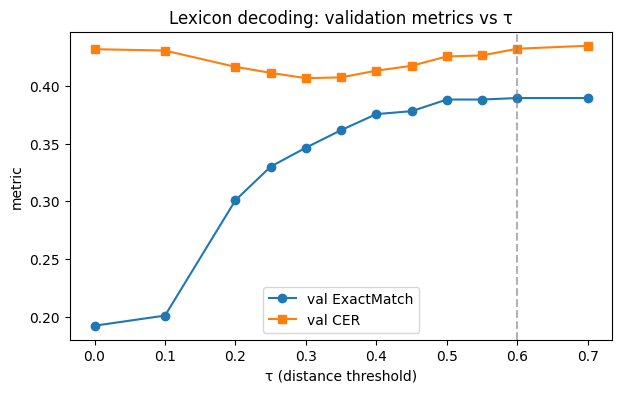

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep.tau, sweep.val_EM, marker="o", label="val ExactMatch")
ax.plot(sweep.tau, sweep.val_CER, marker="s", label="val CER")
ax.axvline(best_tau, color="grey", ls="--", alpha=0.6)
ax.set_xlabel("τ (distance threshold)"); ax.set_ylabel("metric"); ax.legend()
ax.set_title("Lexicon decoding: validation metrics vs τ"); plt.show()

## 7. Final evaluation on TEST at the chosen τ, with seen/unseen breakdown
Compare M2 directly against the baseline (M0). The headline question: does the lexicon
move the **unseen** column off ~zero, where every encoder variant was stuck?

In [19]:
test_df = pd.read_csv(CFG.data_root / CFG.test_csv)
seen_map = dict(zip(test_df[CFG.img_col].astype(str), test_df["seen_in_train"]))

raw_metrics = corpus_metrics(test_raw, test_refs)                 # = baseline (greedy)
m2_dec = lexicon_decode(test_raw, best_tau)
m2_metrics = corpus_metrics(m2_dec, test_refs)

print(f"M0 (greedy, raw)         : CER {raw_metrics['CER']:.4f} | EM {raw_metrics['ExactMatch']:.4f}")
print(f"M2 (lexicon, τ={best_tau}) : CER {m2_metrics['CER']:.4f} | EM {m2_metrics['ExactMatch']:.4f}")

def breakdown(preds):
    groups = {"seen": ([], []), "unseen": ([], [])}
    for p, r, fn in zip(preds, test_refs, test_files):
        key = "seen" if seen_map.get(fn, False) else "unseen"
        groups[key][0].append(p); groups[key][1].append(r)
    return {k: corpus_metrics(P, R) for k, (P, R) in groups.items() if R}

print("\nseen/unseen — M0 (greedy):")
for k, m in breakdown(test_raw).items():
    print(f"  {k:6s} (n={m['n']:3d}): CER {m['CER']:.4f} | EM {m['ExactMatch']:.4f}")
print(f"seen/unseen — M2 (lexicon, τ={best_tau}):")
for k, m in breakdown(m2_dec).items():
    print(f"  {k:6s} (n={m['n']:3d}): CER {m['CER']:.4f} | EM {m['ExactMatch']:.4f}")

M0 (greedy, raw)         : CER 0.4496 | EM 0.1742
M2 (lexicon, τ=0.6) : CER 0.4478 | EM 0.3801

seen/unseen — M0 (greedy):
  seen   (n=613): CER 0.3734 | EM 0.2251
  unseen (n=179): CER 0.6778 | EM 0.0000
seen/unseen — M2 (lexicon, τ=0.6):
  seen   (n=613): CER 0.3540 | EM 0.4910
  unseen (n=179): CER 0.7289 | EM 0.0000


## 8. Safety analysis: did the lexicon introduce confident-but-wrong corrections?
The clinically critical metric. For every example the lexicon CHANGED, classify it:
 - **fix**: raw was wrong, lexicon made it correct  (good)
 - **harmless**: raw wrong, lexicon still wrong       (neutral)
 - **broke**: raw was correct, lexicon made it wrong  (BAD — false correction)
A good operating point maximises fixes while keeping "broke" near zero.

In [20]:
changed = [(r, raw, dec) for raw, dec, r in zip(test_raw, m2_dec, test_refs) if raw != dec]
cats = {"fix": 0, "harmless": 0, "broke": 0}
broke_examples = []
for ref, raw, dec in changed:
    if raw != ref and dec == ref:
        cats["fix"] += 1
    elif raw == ref and dec != ref:
        cats["broke"] += 1; broke_examples.append((ref, raw, dec))
    else:
        cats["harmless"] += 1

print(f"lexicon changed {len(changed)} / {len(test_refs)} predictions:")
for k, v in cats.items():
    print(f"  {k:9s}: {v}")
if broke_examples:
    print("\nfalse corrections (raw was right, lexicon broke it) — inspect these:")
    print(pd.DataFrame(broke_examples, columns=["reference", "raw", "lexicon"]).head(15).to_string(index=False))

pd.DataFrame(changed, columns=["reference", "raw", "lexicon"]).to_csv(
    CFG.out_dir / "m2_changed.csv", index=False)

lexicon changed 618 / 792 predictions:
  fix      : 163
  harmless : 455
  broke    : 0


## 9. Record for the ablation table

| Model | Overall CER | Overall EM | Seen EM | Unseen EM |
|-------|-------------|------------|---------|-----------|
| M0 baseline (greedy) | 0.409 | 0.274 | 0.352 | 0.006 |
| M1 / M1b encoder variants | (worse — documented) | | | 0.000 |
| **M2 CRNN + lexicon (τ=best)** | ? | ? | ? | ? |

**Reading the result:**
- The decisive column is **unseen-EM**. If the lexicon moves it clearly above zero, M2
  delivers the project's core contribution: recovering open-vocabulary names the recogniser
  only approximated. Even a modest jump (e.g. 0.00 → 0.15+) is a strong, defensible result.
- Watch the **safety analysis** (Section 8). If "broke" is non-trivial, lower τ; report the
  accuracy/safety trade-off explicitly — that analysis is itself a Grade-A evaluation point.
- With only the TRAINING-vocabulary lexicon, unseen names that are absent from training
  cannot be recovered; an external formulary (set `CFG.formulary_path`) is what unlocks
  the rest. State this clearly as a limitation + future-work lever.

**Next (M3):** structured {name, strength, unit} decoding — apply the lexicon to the NAME
field only, validate strength/unit separately, and add field-level + clinical-error metrics.